In [1]:
import numpy as np                           
import pandas as pd                                 
import matplotlib.pyplot as plt 

from sklearn.pipeline import Pipeline           
from sklearn.compose import ColumnTransformer     
from sklearn.preprocessing import StandardScaler, RobustScaler      
from sklearn.preprocessing import OneHotEncoder       
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR 
from sklearn.model_selection import train_test_split, learning_curve

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [2]:
data = pd.read_csv("..\\data\\train_clean.csv")
data.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.0,58.0,1.75,MARUTI,WAGON R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.0,126.0,12.50,HYUNDAI,CRETA 1.6 CRDI SX OPTION
2,Chennai,2011,46000,Petrol,Manual,First,18.0,88.0,4.50,HONDA,JAZZ V
3,Chennai,2012,87000,Diesel,Manual,First,20.0,88.0,6.00,MARUTI,ERTIGA VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.0,140.0,17.74,AUDI,A4 NEW 2.0 TDI MULTITRONIC


In [3]:
X = data.drop(columns=["Price"])
y = data["Price"] 

In [4]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", RobustScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                                           
    test_size=0.2,                              
    random_state=42                                
)

In [6]:
svr_model1 = Pipeline(steps=[
    ("preprocess", preprocess),                     
    ("model", SVR(kernel="poly", C=10, gamma="scale", epsilon=0.1)) 
])

svr_model1.fit(X_train, y_train)                       
print("SVR trained (fixed hyperparameters).") 

SVR trained (fixed hyperparameters).


In [7]:
def evaluate_regression(model, X_test, y_test, name="model"):
    """
    Evaluate a regression model on the test set using:
    - MAE
    - RMSE
    - R²
    Also plots Actual vs Predicted.
    """
    preds = model.predict(X_test)                     

    mae = mean_absolute_error(y_test, preds)          
    rmse = np.sqrt(mean_squared_error(y_test, preds)) 
    r2 = r2_score(y_test, preds)                      

    print(f"\n--- {name} ---")                        
    print(f"MAE : {mae:.4f}")                         
    print(f"RMSE: {rmse:.4f}")                        
    print(f"R^2 : {r2:.4f}")                          

    plt.figure()                                      
    plt.scatter(y_test, preds, s=8)                   
    plt.title(f"{name}: Actual vs Predicted")         
    plt.xlabel("Actual")                              
    plt.ylabel("Predicted")                           
    plt.show()                                        

    return mae, rmse, r2 


--- SVR (fixed params) ---
MAE : 1.2583
RMSE: 2.8714
R^2 : 0.9331


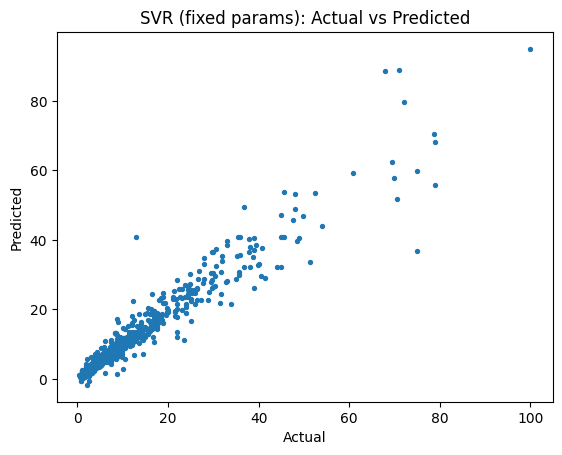

In [8]:
svr_scores = evaluate_regression(                      
    svr_model1,                                        
    X_test,                                           
    y_test,                                            
    "SVR (fixed params)"                               
)

In [9]:
import pickle

with open('modele_svr.pkl', 'wb') as fichier_modele:
    pickle.dump(svr_model1, fichier_modele)

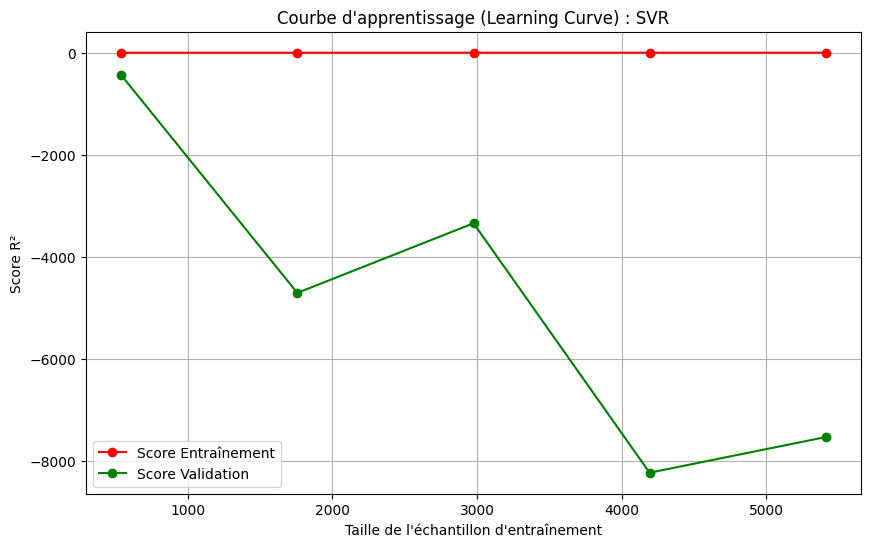

In [29]:
svr_model = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", SVR(kernel="poly", C=10, gamma="scale", epsilon=0.1))                      
])

taille_train, scrore_train, score_test = learning_curve(svr_model, X, y, cv=10, scoring='r2', random_state=42)

# 1. Calculer les moyennes des scores (car il y a plusieurs résultats par test via cv=5)
train_scores_mean = np.mean(scrore_train, axis=1)
test_scores_mean = np.mean(score_test, axis=1)

# 2. Création du graphique
plt.figure(figsize=(10, 6))

# Tracé de la courbe d'entraînement (Rouge)
plt.plot(taille_train, train_scores_mean, 'o-', color="r", label="Score Entraînement")

# Tracé de la courbe de test/validation (Vert)
plt.plot(taille_train, test_scores_mean, 'o-', color="g", label="Score Validation")

# 3. Habillage du graphe
plt.title("Courbe d'apprentissage (Learning Curve) : SVR")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score R²")
plt.legend(loc="best")
plt.grid(True)

plt.show()